### 1. Import Libaries

In [1]:
import pandas as pd        
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

 ### 2. Load Dataset

In [2]:
df=pd.read_csv(r"insurance.csv")
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


### 3. Basic Inspection

In [3]:
df.shape

(1338, 7)

In [4]:
print('---Dataset Info----\n')
print(df.info())
print('-----Statistical Summary---\n')
print(df.describe())

---Dataset Info----

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
-----Statistical Summary---

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.

In [5]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
df.drop_duplicates(inplace=True)

### 4.Univariate Analysis

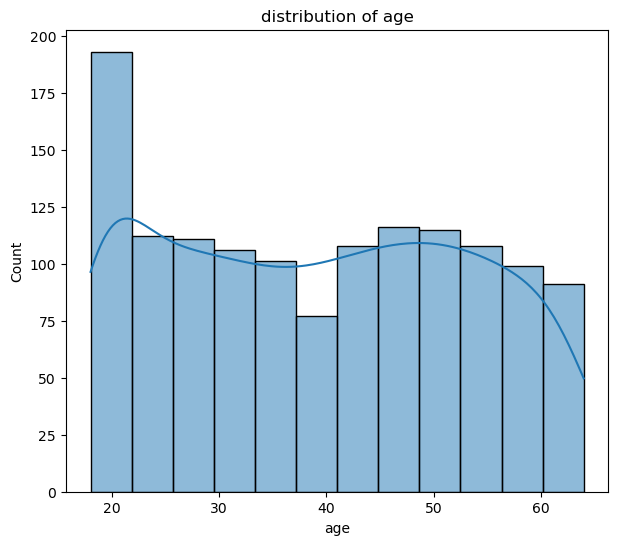

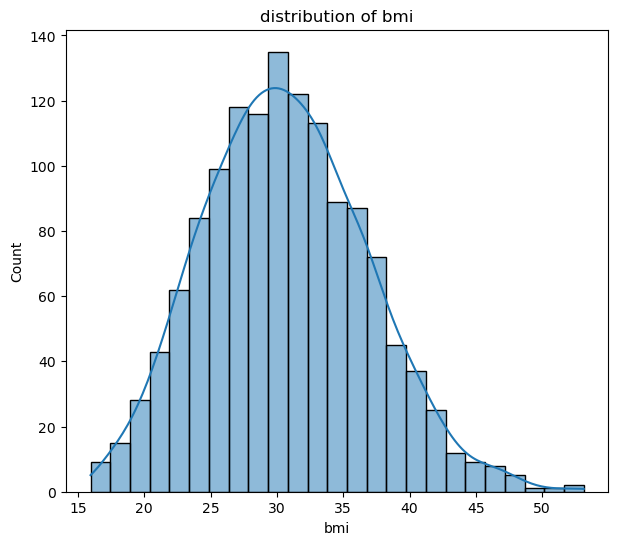

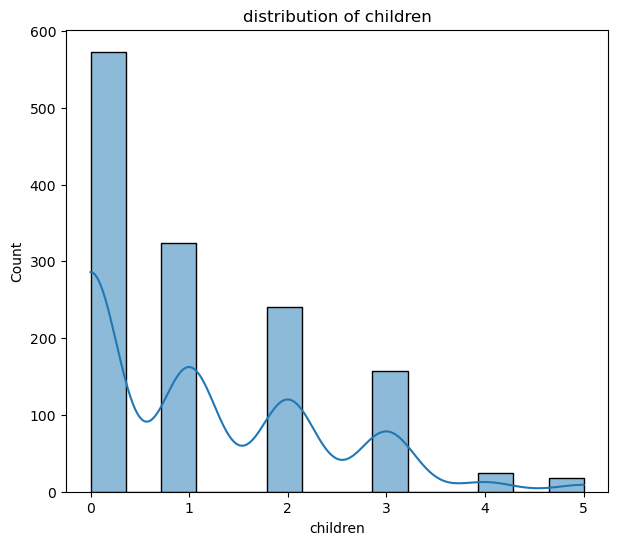

In [7]:
# Numerical Distriutions
num_cols=['age','bmi','children']
for col in num_cols:
    plt.figure(figsize=(7,6))
    sns.histplot(df[col],kde=True)
    plt.title(f'distribution of {col}')
    # plt.savefig(f'images/{col}_distribution.png',dpi=300,bbox_inches='tight')
    plt.show()

### Categorical Distribution

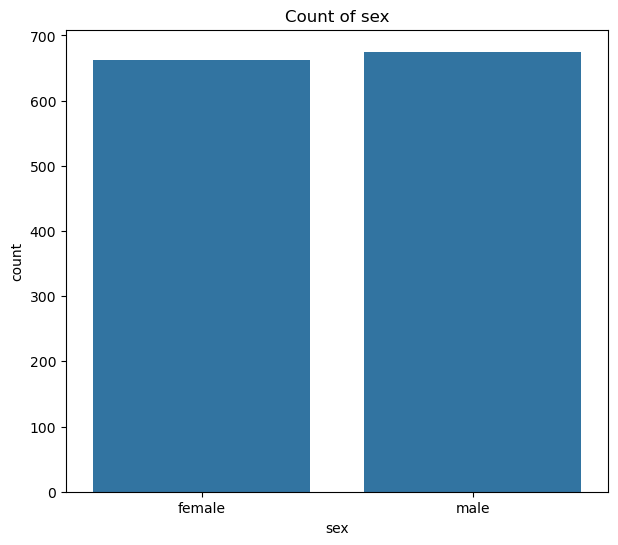

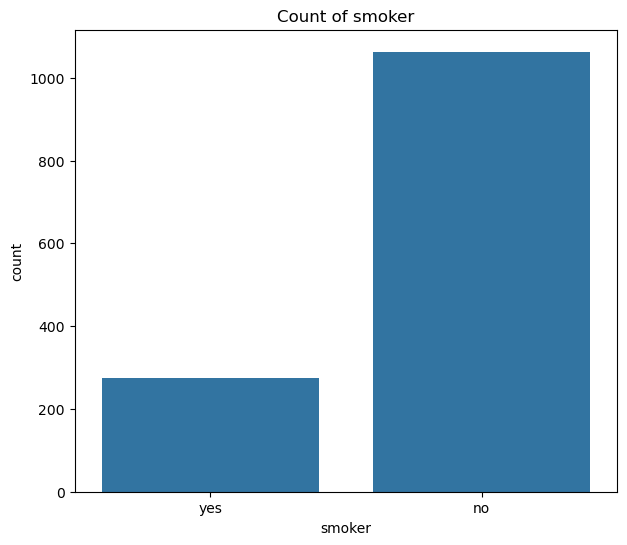

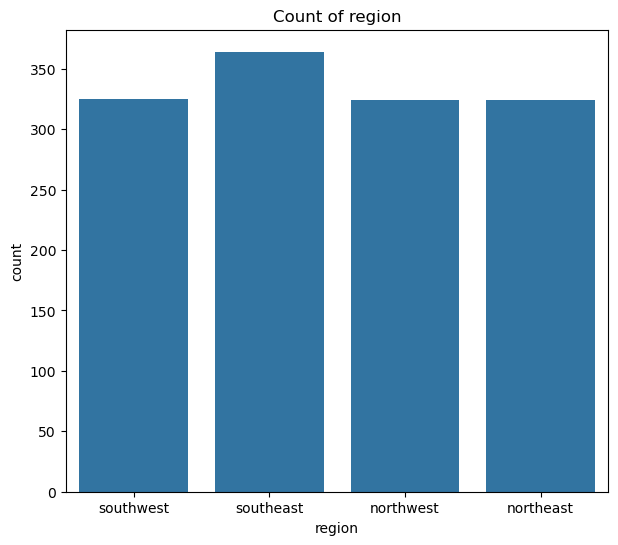

In [8]:
cat_col=['sex','smoker','region']
for col in cat_col:
    plt.figure(figsize=(7,6))
    sns.countplot(x=df[col])
    plt.title(f'Count of {col}')
    # plt.savefig(f'images/{col}_count.png',dpi=300,bbox_inches='tight')
    plt.show()

### 5.Bivariate Analysis

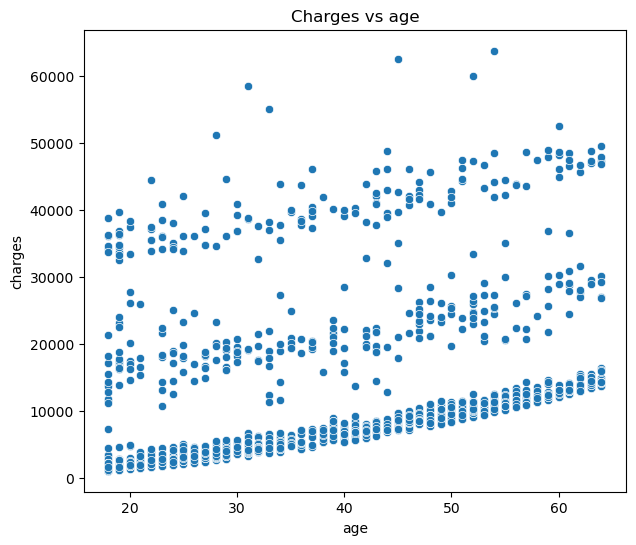

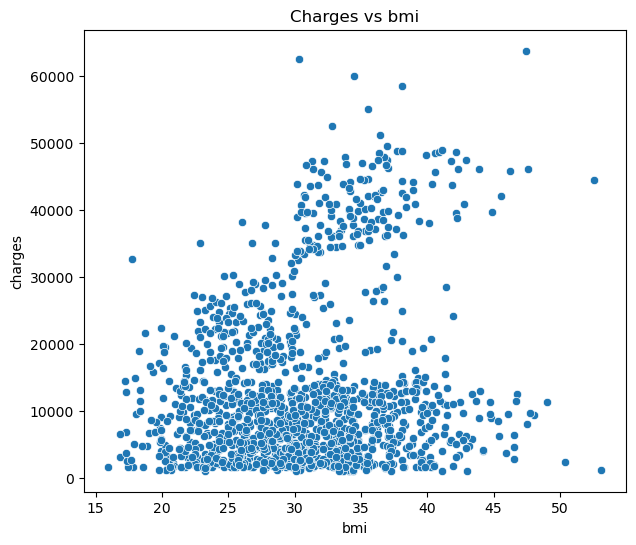

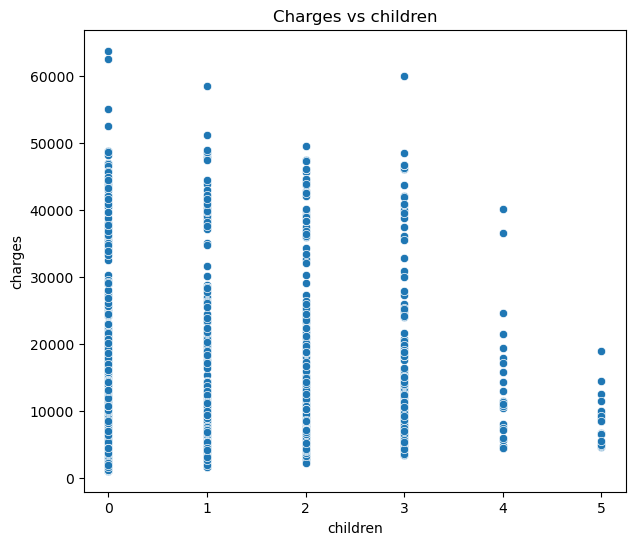

In [9]:
# Charges vs Numerical Features
for col in ['age','bmi','children']:
    plt.figure(figsize=(7,6))
    sns.scatterplot(x=df[col],y=df['charges'])
    plt.title(f'Charges vs {col}')
    # plt.savefig(f'images/charges_vs_{col}.png',dpi=300,bbox_inches='tight')
    plt.show()

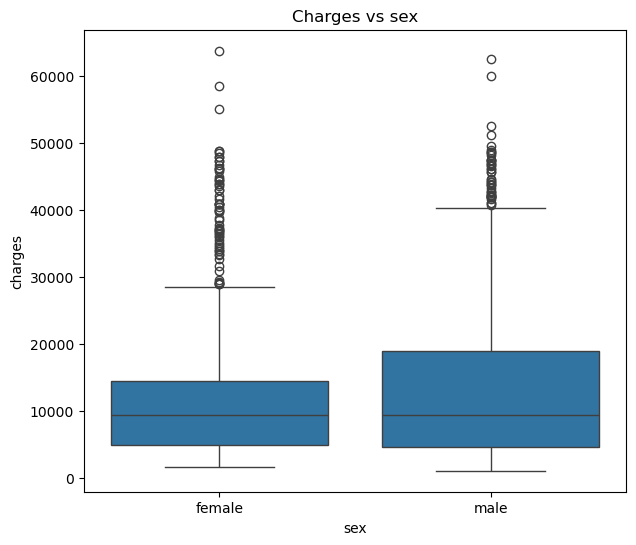

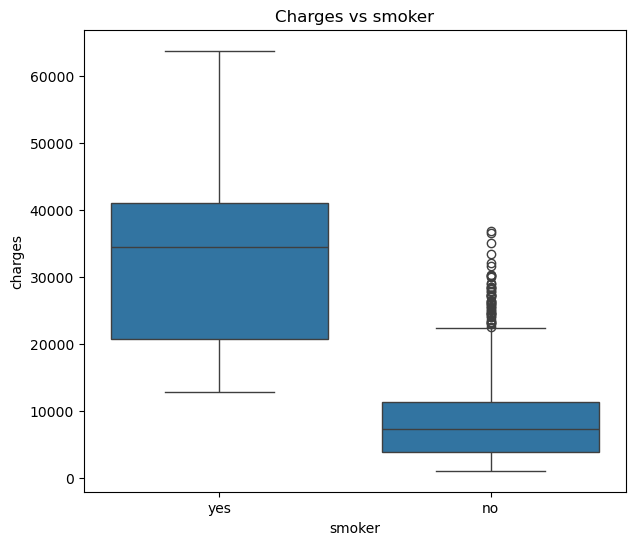

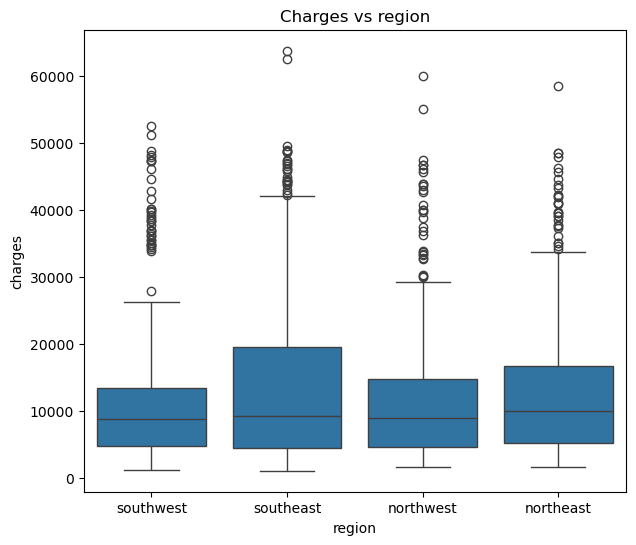

In [10]:
#Charges vs Categorical Features
for col in ['sex','smoker','region']:
    plt.figure(figsize=(7,6))
    sns.boxplot(x=df[col],y=df['charges'])
    plt.title(f'Charges vs {col}')
    # plt.savefig(f'images/charges_vs_{col}.png',dpi=300,bbox_inches='tight')
    plt.show()

### 6.Correlation Analysis

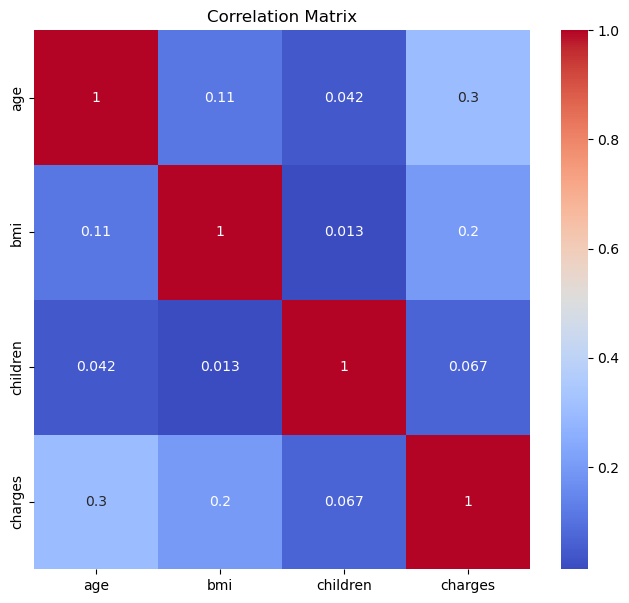

In [11]:
plt.figure(figsize=(8,7))
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title('Correlation Matrix')
# plt.savefig('images/correlation_matrix.png',dpi=300,bbox_inches='tight')
plt.show()

### 7.Multivariate Analysis

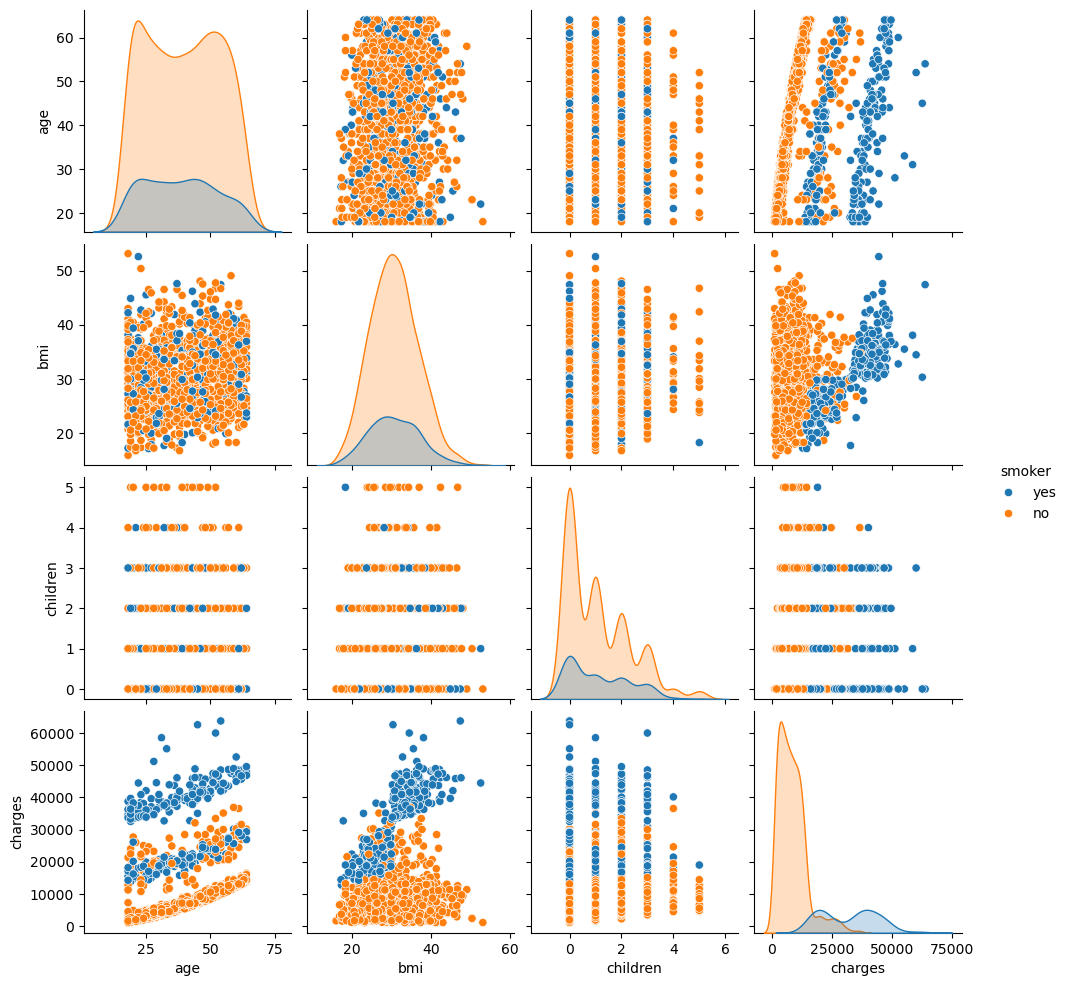

In [12]:
sns.pairplot(df,hue='smoker')
# plt.savefig('images/Pairplot.png',dpi=300,bbox_inches='tight')
plt.show()

### 8.PreProcessing

In [13]:
#Encoder categorical Data
df=pd.get_dummies(df,dtype='int32',drop_first=True,)
df

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,1,0,1,0,0
1334,18,31.920,0,2205.98080,0,0,0,0,0
1335,18,36.850,0,1629.83350,0,0,0,1,0
1336,21,25.800,0,2007.94500,0,0,0,0,1


The independent variable (X) is the input variable that influences the dependent variable (Y).In the dataset the variable are age,bmi,chlidren,sex_male,smoker_yes.region_northwest,region_southeast,region_southwest,charges .So independent variable are  age,bmi,chlidren,sex_male,smoker_yes.region_northwest,region_southeast,region_southwest and charges is dependent variable So we drop the column charge

In [14]:
# Features
x=df.drop('charges',axis=1)
x

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,0,1,0,0,1
1,18,33.770,1,1,0,0,1,0
2,28,33.000,3,1,0,0,1,0
3,33,22.705,0,1,0,1,0,0
4,32,28.880,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...
1333,50,30.970,3,1,0,1,0,0
1334,18,31.920,0,0,0,0,0,0
1335,18,36.850,0,0,0,0,1,0
1336,21,25.800,0,0,0,0,0,1


The target variable is the output variable (Y) that the model tries to predict using input variables. the target variable is charges 

In [15]:
#Target
y=df['charges']
y

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1337, dtype: float64

### 9.Train-Test-Split
Train-Test Split divides a dataset into training data and testing data to evaluate a machine learning model.test_size means that 20% data is for testing and 80% for training.random_state fixes randomness so results remain the same every time the code runs. 

In [16]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,random_state=42,test_size=0.2)

In [17]:
print(xtrain.shape,ytrain.shape,xtest.shape,ytest.shape)

(1069, 8) (1069,) (268, 8) (268,)


### 10.MODELS
Linear Regression is a supervised learning algorithm used to predict a continuous target variable using a linear relationship between variables.

In [18]:
#---------------Linear Regression-------------------
model=LinearRegression()

In [19]:
model.fit(xtrain,ytrain)

LinearRegression()

In [20]:
print('Linear_Regression_Train_Score:',model.score(xtrain,ytrain))
print('Linear_Regression_Test_Score:',model.score(xtest,ytest))

Linear_Regression_Train_Score: 0.7299057809339075
Linear_Regression_Test_Score: 0.8069287081198011


In [21]:
y_prediction=model.predict(xtest)
y_prediction

array([ 8.14369388e+03,  5.73711568e+03,  1.43693149e+04,  3.17455136e+04,
        8.96238666e+03,  1.31497224e+04,  3.04467607e+04,  1.45328881e+03,
        1.06330184e+04,  1.13189438e+04,  1.03778536e+04,  3.31184377e+04,
        3.10772527e+04,  1.74119253e+04,  1.08016743e+04,  9.52889964e+03,
        4.16103784e+03,  3.17315373e+04,  3.21938875e+03,  5.22992460e+03,
        3.54979004e+03,  3.02837740e+04,  1.48989509e+04,  3.04569093e+04,
        3.11077668e+04,  5.51196081e+03,  3.55030401e+04,  3.65704810e+04,
        1.14123133e+04,  1.42056990e+04,  6.50234029e+03,  1.27246945e+04,
        3.99806590e+02,  1.20883980e+04,  3.96592069e+04,  1.23395540e+04,
        4.74412279e+03,  3.91903157e+03,  3.08606789e+04,  8.95870663e+03,
        7.05389441e+03,  3.01125636e+04,  3.47804324e+04,  1.22916189e+04,
        7.35739310e+03,  3.42060530e+03,  6.21243471e+03,  8.98345200e+03,
        4.26401828e+03,  9.01992870e+03,  6.60149578e+03,  1.20802337e+04,
        3.12447687e+04,  

In [22]:
#To predict with unseen data, you give the model new input data that was not used during training or testing.
new_data=[[21,29.12,0,1,1,1,0,0]]
new_predict=model.predict(new_data)
new_predict

c:\Users\abhig\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([25984.8198734])

In [23]:
#----------Polynomial Regression-----------------
poly=PolynomialFeatures(degree=2)
xtrain_poly=poly.fit_transform(xtrain)
xtest_poly=poly.transform(xtest)

In [24]:
lr_poly=LinearRegression()
lr_poly.fit(xtrain_poly,ytrain)


LinearRegression()

In [25]:
ypred_poly=lr_poly.predict(xtest_poly)
ypred_poly

array([ 8353.84308898,  6542.11918975, 14316.73674593, 35908.93406513,
        5652.79736389, 11043.96072984, 41404.59938675,  3085.07624772,
        8734.84472265, 12346.93094977, 12841.73689609, 27954.49639603,
       35077.12625781, 14054.61913174,  9574.36117895,  8989.2684769 ,
        3353.91389387, 36114.54268087,  4129.06539415,  5841.64017749,
        3122.34618085, 27054.48888027, 10476.24527684, 28353.11244489,
       35708.05468415,  6963.11798135, 45656.39277055, 42511.8702368 ,
       11534.46973331, 12439.38086181,  6273.66203349, 10897.02348058,
        4212.57677537, 13936.19465617, 57344.92884446, 11371.46150017,
        6142.07832193,  6993.32844002, 20372.14012027, 10290.47892016,
        5022.08400106, 17520.86620716, 39561.41757272, 11031.83473817,
        9354.14555481,  4018.75189627,  4769.98114709,  8583.92033589,
        5652.60475114,  8316.80951139,  6266.02916583,  6124.11237092,
       25597.8624426 ,  2936.51081915,  8279.34502971,  9907.58545569,
      

In [26]:
print('Polynomial_Regression_train_score',lr_poly.score(xtrain_poly,ytrain))
print('Polynomial_Regression_test_score',lr_poly.score(xtest_poly,ytest))

Polynomial_Regression_train_score 0.8340263483080009
Polynomial_Regression_test_score 0.8825298972468526


In [27]:
#--------------Random Forest Regressor------------------
rf=RandomForestRegressor(random_state=42)


In [28]:
param_grid={
    'n_estimators':[100,200],
    'max_depth':[None,10,20],
    'min_samples_split':[2,5]
}

In [29]:
rf_grid=GridSearchCV(estimator=rf,param_grid=param_grid,cv=5,scoring='r2',n_jobs=-1)
rf_grid.fit(xtrain,ytrain)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2')

In [30]:
y_pred_rf=rf_grid.predict(xtest)
y_pred_rf

array([ 9393.62449934,  8639.52547489, 12462.19048726, 42725.51941058,
        5698.45136047, 10040.89040301, 38223.64635656,  2271.50495194,
        9866.04295766, 11168.71758934, 14615.63775206, 24072.23471573,
       42399.03131265, 14784.64262149,  6078.58805183,  9594.2530193 ,
        6043.67247279, 39858.98031592,  5945.72477187,  5442.23054033,
        4488.84440486, 20372.79479585, 10497.30894561, 21258.57285219,
       38915.47806823, 15948.21091579, 42919.28865903, 46061.25042202,
       10643.79575742, 12262.34971644,  4026.82601827,  9312.79299855,
        3156.74886576, 14985.63514599, 47386.91979834, 10074.16090566,
        7490.02471967,  6036.06726365, 24322.0502305 ,  9241.86151949,
        2437.83859351, 21333.6567203 , 41508.76397444,  9495.3222764 ,
        9239.44946926,  4213.06534176,  3198.21091576,  8363.61564274,
        6580.32594921, 10040.19720298,  5314.04398923,  8805.20497574,
       22201.23880922,  5086.31807815,  7847.5995904 , 10527.32867208,
      

In [31]:
print('train score:',rf_grid.score(xtrain,ytrain))
print('test score:',rf_grid.score(xtest,ytest))

train score: 0.9437473733565763
test score: 0.888069114282888


In [32]:
xgb=XGBRegressor(random_state=42)

In [33]:
param_grid_xgb={
    'n_estimator':[100,200],
    'learnig_rate':[0.05,0.1],
    'max_depth':[3,5,7]
}

In [34]:
xgb_grid=GridSearchCV(estimator=xgb,param_grid=param_grid_xgb,cv=5,scoring='r2',n_jobs=-1)

In [35]:
xgb_grid.fit(xtrain,ytrain)

c:\Users\abhig\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [07:41:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "learnig_rate", "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, max_bin=None,
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learnig_rate': [0.05, 0.1], 'max_depth': [3, 5, 7],
                         'n_estimator': [100, 200]},
             scoring='r2')

In [36]:
ypred_xgb=xgb_grid.predict(xtest)
ypred_xgb

array([ 9708.371 ,  8467.087 , 12743.935 , 38216.117 ,  6140.0386,
       11690.75  , 39517.332 ,  7397.418 , 10161.271 , 10851.871 ,
       12236.614 , 28673.012 , 39995.805 , 14945.02  , 11484.38  ,
        9041.203 ,  6342.293 , 40260.277 ,  3142.787 ,  4412.166 ,
        4128.053 , 20037.018 ,  9474.713 , 20703.74  , 38196.258 ,
       14642.68  , 42433.746 , 45111.742 , 11575.585 , 15660.885 ,
        4329.052 , 10249.276 ,  3458.6145, 15547.446 , 48034.316 ,
        9063.315 ,  9884.658 ,  5007.7407, 20923.824 ,  9120.729 ,
        2666.3242, 20931.172 , 42230.492 ,  9815.542 ,  8384.472 ,
        3057.019 ,  3771.7966,  7186.617 ,  5849.6953,  9327.727 ,
        6870.648 ,  6824.7695, 23508.84  ,  5182.122 ,  8824.82  ,
       10459.987 , 10065.607 ,  5837.3794, 41428.69  ,  8432.851 ,
       13851.539 ,  5732.912 , 14823.191 ,  1363.8634, 10361.38  ,
       12791.798 ,  6199.8584, 24898.467 , 18156.008 , 17185.428 ,
       11748.255 , 10779.873 ,  5655.7524,  3187.6545, 11034.2

In [37]:
print('train score:',xgb_grid.score(xtrain,ytrain))
print('test score:',xgb_grid.score(xtest,ytest))

train score: 0.9224327234586864
test score: 0.8900827834863758


### 11.EVALUATION FUNCTION

In [38]:
def evaluate(ytrue,ypred,model_name):
    mse=mean_squared_error(ytrue,ypred)
    r2_scores=r2_score(ytrue,ypred)
    print(f'\n{model_name} ')
    print('MSE:',mse)
    print('R2:',r2_scores)
    return r2_scores

In [39]:
#------------Evaluate all model------------
r2_linear=evaluate(ytest,y_prediction,'Linear Regression')
r2_poly=evaluate(ytest,ypred_poly,'Polynomial Regression')
r2_rf=evaluate(ytest,y_pred_rf,'Random Forest (GridSearch)')
r2_xgb=evaluate(ytest,ypred_xgb,'XGBoost (GridSearch)')


Linear Regression 
MSE: 35478020.67523561
R2: 0.8069287081198011

Polynomial Regression 
MSE: 21585843.724421877
R2: 0.8825298972468526

Random Forest (GridSearch) 
MSE: 20567979.00401059
R2: 0.888069114282888

XGBoost (GridSearch) 
MSE: 20197955.076896917
R2: 0.8900827834863758


### 12.COMPARISON

In [40]:
results=pd.DataFrame({
    'model':['Linear','Polynomial','Random Forest','XGBoost'],
    'R2_scores':[r2_linear,r2_poly,r2_rf,r2_xgb]
})
print('\n----- Model Comparison-----')
print(results)


----- Model Comparison-----
           model  R2_scores
0         Linear   0.806929
1     Polynomial   0.882530
2  Random Forest   0.888069
3        XGBoost   0.890083


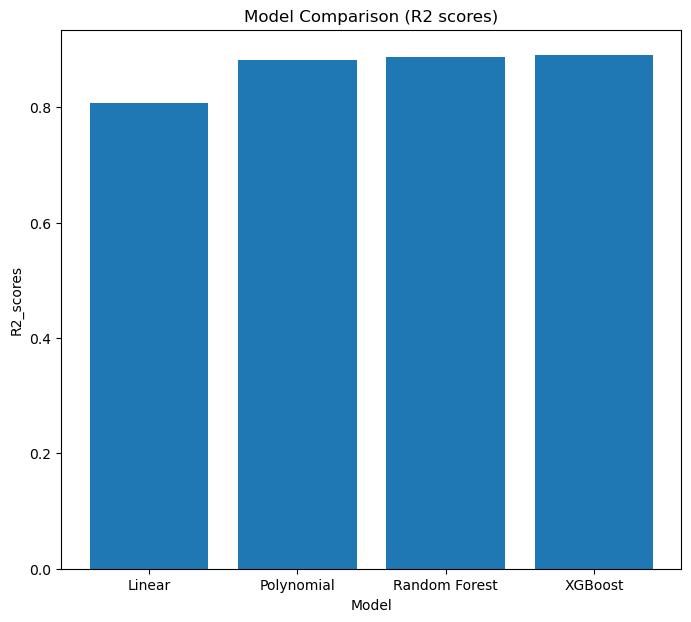

In [41]:
#--------------Plot Comparison-------------
plt.figure(figsize=(8,7))
plt.bar(results['model'],results['R2_scores'])
plt.title('Model Comparison (R2 scores)')
plt.xlabel('Model')
plt.ylabel('R2_scores')
# plt.savefig('images/Plot_Comparsion.png',dpi=300,bbox_inches='tight')
plt.show()

### 13.BEST MODEL

In [42]:
best_model=max([
    ('Linear',r2_linear),
    ('Polynomial',r2_poly),
    ('Random Forest',r2_rf),
    ('XGBoost',r2_xgb)
])
print('\n Best model:',best_model)


 Best model: ('XGBoost', 0.8900827834863758)


### 14.Save Model

In [43]:
import pickle
#save the best model
with open('Best_model.pkl','wb') as f:
    pickle.dump(xgb_grid,f)
#Save column orders
with open('Column_order.pkl','wb') as f:
    pickle.dump(x.columns.tolist(),f)

## END OF PROJECT